In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.shape

(891, 12)

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [10]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [11]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [12]:
df["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [15]:
import matplotlib.pyplot as plt

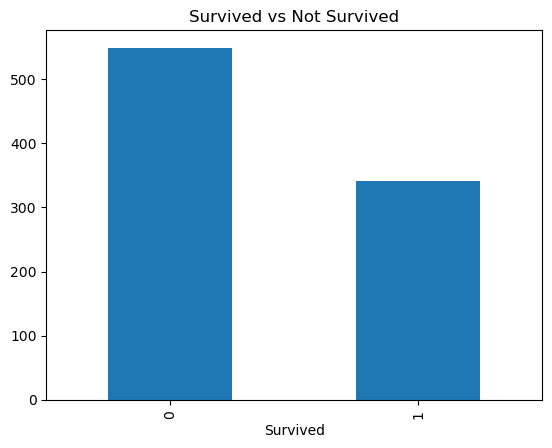

In [16]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survived vs Not Survived")
plt.show()

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [19]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [20]:
df = df.drop(columns=["Cabin"])

In [21]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()

In [25]:
df["Sex"] = le.fit_transform(df["Sex"])

In [26]:
df["Embarked"] = le.fit_transform(df["Embarked"])

In [27]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:

from sklearn.tree import DecisionTreeClassifier

In [44]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
from sklearn.metrics import accuracy_score

In [46]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7821229050279329


In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

prediction = model.predict(new_passenger)

[[83 22]
 [17 57]]


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



In [36]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
1,Sex,0.310280
5,Fare,0.242798
2,Age,0.217041
0,Pclass,0.111619
3,SibSp,0.056342
4,Parch,0.037738
6,Embarked,0.024181


In [37]:
new_passenger = [[1, 0, 25, 0, 0, 80, 0]]

In [40]:
import pandas as pd

new_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": [0],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [80],
    "Embarked": [0]
})

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Survived


In [48]:
prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Prediction: Passenger is likely to SURVIVE")
else:
    print("Prediction: Passenger is likely to NOT SURVIVE")

Prediction: Passenger is likely to SURVIVE


In [49]:
probability = model.predict_proba(new_passenger)

print("Probability of Not Surviving:", probability[0][0])
print("Probability of Surviving:", probability[0][1])

Probability of Not Surviving: 0.0
Probability of Surviving: 1.0


In [50]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,0
1,0,1
2,0,1
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


In [51]:
import joblib

joblib.dump(model, "titanic_decision_tree_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Conclusion

A Decision Tree Classifier was trained on the Titanic dataset to predict passenger survival.

The dataset was cleaned by handling missing values and removing unnecessary columns.

Categorical features were encoded before training.

The model achieved an accuracy of approximately 78%.

The trained model can successfully predict whether a new passenger is likely to survive based on the selected features.